In [36]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('Dataset.xlsx')

## 1. How many phones for each brand?

In [4]:
phone_count = df['Brand'].value_counts().reset_index()
phone_count.columns = ['Brand', 'Phone_Count']
print(phone_count)

       Brand  Phone_Count
0    Samsung         1560
1     realme          709
2      Apple          515
3      redmi          417
4    Infinix          355
5   motorola          346
6       Oppo          295
7       lava          279
8       vivo          256
9    OnePlus          240
10      POCO          240
11     Tecno          205
12      IQOO          158
13   ai_plus           75
14   nothing           44
15    Google           34


The count represents the number of product listings/variants in the dataset, which may include multiple configurations (such as color, storage, and memory) of the same base product. It does not necessarily reflect the number of distinct product models.

## 2. Highest, Lowest, Average Rating by each brand

In [5]:
rating_stats = df.groupby('Brand')['Rating'].agg(['max', 'min', 'mean']).round(2)
rating_stats.columns = ['Highest_Rating', 'Lowest_Rating', 'Average_Rating']
print(rating_stats)

          Highest_Rating  Lowest_Rating  Average_Rating
Brand                                                  
Apple                5.0            3.9            4.57
Google               4.6            3.0            4.41
IQOO                 4.7            3.9            4.40
Infinix              4.5            3.9            4.24
OnePlus              5.0            3.2            4.34
Oppo                 5.0            3.8            4.35
POCO                 4.5            3.8            4.24
Samsung              4.9            3.3            4.27
Tecno                4.5            3.7            4.21
ai_plus              4.5            3.8            4.10
lava                 4.4            2.6            3.90
motorola             4.6            2.7            4.23
nothing              4.6            4.4            4.47
realme               4.8            3.0            4.32
redmi                4.5            1.0            4.17
vivo                 4.9            3.6         

Ratings are based on available listings. Brands with fewer listings may have less statistical reliability.

## 3. Highest, Lowest, Average Price by each brand

In [6]:
price_stats = df.groupby('Brand')['Current Price'].agg(['max', 'min', 'mean']).round(2)
price_stats.columns = ['Highest_Price', 'Lowest_Price', 'Average_Price']
print(price_stats)

          Highest_Price  Lowest_Price  Average_Price
Brand                                               
Apple          222900.0       14999.0       91992.29
Google         172999.0       21216.0       74534.82
IQOO            79900.0       10498.0       30292.35
Infinix         54999.0        6199.0       13908.27
OnePlus        125000.0       11288.0       36819.22
Oppo           169999.0        7490.0       32897.99
POCO            48999.0        5299.0       21377.16
Samsung        216999.0        4790.0       38295.56
Tecno           37213.0        6699.0       13868.67
ai_plus         49999.0        7999.0       14959.00
lava            23999.0        3299.0        9826.37
motorola       169999.0        5799.0       23875.84
nothing         59999.0       23999.0       36726.27
realme          79999.0        3999.0       19299.75
redmi           57899.0        4499.0       14711.79
vivo           159999.0        7499.0       28033.90


In [8]:
# Check for common keywords
keypad_keywords = ['keypad', 'feature phone', 'button', 'basic phone', 'non-smartphone']

# See if any listings contain these
for keyword in keypad_keywords:
    print(f"{keyword}: {df[df['Product Name'].str.contains(keyword, case=False, na=False)].shape[0]}")

keypad: 0
feature phone: 0
button: 0
basic phone: 0
non-smartphone: 0


In [11]:
# Filter to keep only smartphones
# ============================================
# Assuming your storage column is named 'Storage_GB' or 'Storage'
# If it's named differently, change it below

smartphones = df[
    (df['Storage'] >= 4) &  # At least 4GB storage
    (df['Current Price'] >= 3000)   # At least ₹3,000
].copy()


removed = df[~df.index.isin(smartphones.index)]

print("="*50)
print("DATA CLEANING SUMMARY")
print("="*50)
print(f"Total listings: {len(df)}")
print(f"Smartphones kept: {len(smartphones)}")
print(f"Feature phones removed: {len(removed)}")
print(f"Removed percentage: {(len(removed)/len(df)*100):.1f}%")
print("\n📱 Feature phones removed by brand:")
print(removed['Brand'].value_counts())
print("\n✅ Smartphones by brand:")
print(smartphones['Brand'].value_counts())


print("\n🔍 Sample of removed phones:")
print(removed[['Brand', 'Product Name', 'Storage', 'Current Price']].head(10))


# df = smartphones.copy()

DATA CLEANING SUMMARY
Total listings: 5728
Smartphones kept: 5709
Feature phones removed: 19
Removed percentage: 0.3%

📱 Feature phones removed by brand:
Brand
lava        8
Samsung     8
motorola    1
OnePlus     1
realme      1
Name: count, dtype: int64

✅ Smartphones by brand:
Brand
Samsung     1552
realme       708
Apple        515
redmi        417
Infinix      355
motorola     345
Oppo         295
lava         271
vivo         256
POCO         240
OnePlus      239
Tecno        205
IQOO         158
ai_plus       75
nothing       44
Google        34
Name: count, dtype: int64

🔍 Sample of removed phones:
         Brand                                Product Name  Storage  \
1361      lava  LAVA Iris 352 Flair (Champagne Gold, 2 GB)        2   
1383      lava                LAVA Iris 404e (White, 1 GB)        1   
1384      lava                LAVA Iris 404e (Black, 1 GB)        1   
1391      lava                 LAVA Iris 502 (Black, 2 GB)        2   
1393      lava             LAVA

In [14]:
def extract_storage_corrected(text):
    """Extract storage in GB, handling TB correctly"""
    if pd.isna(text):
        return 0
    
    text = str(text)
    
    # Check for TB first (convert to GB)
    match_tb = re.search(r'(\d+(?:\.\d+)?)\s*TB', text, re.IGNORECASE)
    if match_tb:
        return float(match_tb.group(1)) * 1000  # Convert TB to GB
    
    # Check for GB
    match_gb = re.search(r'(\d+(?:\.\d+)?)\s*GB', text, re.IGNORECASE)
    if match_gb:
        return float(match_gb.group(1))
    
    # Check for MB (convert to GB)
    match_mb = re.search(r'(\d+(?:\.\d+)?)\s*MB', text, re.IGNORECASE)
    if match_mb:
        return float(match_mb.group(1)) / 1024
    
    return 0

# Re-apply to your dataframe
df['Storage'] = df['Product Name'].apply(extract_storage_corrected)

In [16]:
smartphones = df[
    (df['Storage'] >= 4) &
    (df['Current Price'] >= 3000)
].copy()

# Check results
removed = df[~df.index.isin(smartphones.index)]
print(f"Total removed: {len(removed)}")
print("\nRemoved phones (should now be only feature phones):")
print(removed[['Brand', 'Product Name', 'Storage', 'Current Price']])

Total removed: 31

Removed phones (should now be only feature phones):
        Brand                                       Product Name   Storage  \
700   Infinix        Infinix Note 50s (Enchanted Purple, 128 MB)  0.125000   
717   Infinix           Infinix Note 50s (Titanium Grey, 128 MB)  0.125000   
948   Infinix        Infinix Note 50s (Enchanted Purple, 128 MB)  0.125000   
949   Infinix           Infinix Note 50s (Titanium Grey, 128 MB)  0.125000   
950   Infinix        Infinix Note 50s (Enchanted Purple, 128 MB)  0.125000   
951   Infinix           Infinix Note 50s (Titanium Grey, 128 MB)  0.125000   
952   Infinix        Infinix Note 50s (Sea Breeze Green, 128 MB)  0.125000   
953   Infinix        Infinix Note 50s (Sea Breeze Green, 128 MB)  0.125000   
1139     lava          LAVA YUVA STAR 2 (SPARKLING IVORY, 64 MB)  0.062500   
1319     lava  LAVA A97 2GB Plus 4G with VoLTE (Black & Gold,...  2.000000   
1360     lava             LAVA A97 2GB Plus (Blue, Black, 16 GB)  2.000

In [17]:
import pandas as pd
import re

def extract_storage_final(text):
    """Extract storage in GB, handling all edge cases"""
    if pd.isna(text):
        return 0
    
    text = str(text)
    
    # Check for "X+Y GB" format (e.g., "32+3 GB") - take the first number
    match_plus = re.search(r'(\d+)\s*\+\s*\d+\s*GB', text, re.IGNORECASE)
    if match_plus:
        return float(match_plus.group(1))
    
    # Check for "X GB" format
    match_gb = re.search(r'(\d+(?:\.\d+)?)\s*GB', text, re.IGNORECASE)
    if match_gb:
        return float(match_gb.group(1))
    
    # Check for "X MB" - BUT be careful! Many listings use "MB" when they mean "GB"
    match_mb = re.search(r'(\d+(?:\.\d+)?)\s*MB', text, re.IGNORECASE)
    if match_mb:
        mb_value = float(match_mb.group(1))
        # If MB value is large (>= 32), it's actually GB (mislabeled)
        if mb_value >= 32:
            return mb_value  # Treat as GB
        else:
            return mb_value / 1024  # Actually MB, convert to GB
    
    # Check for "X TB" format
    match_tb = re.search(r'(\d+(?:\.\d+)?)\s*TB', text, re.IGNORECASE)
    if match_tb:
        return float(match_tb.group(1)) * 1000
    
    return 0  # No storage found

# Apply the fixed extraction
df['Storage_GB'] = df['Product Name'].apply(extract_storage_final)

# Filter smartphones
smartphones = df[
    (df['Storage_GB'] >= 4) &  # At least 4GB
    (df['Current Price'] >= 3000)  # At least ₹3000
].copy()

# Check what's now removed
removed = df[~df.index.isin(smartphones.index)]

print("="*50)
print("FINAL DATA CLEANING SUMMARY (with fixed parsing)")
print("="*50)
print(f"Total listings: {len(df)}")
print(f"Smartphones kept: {len(smartphones)}")
print(f"Feature phones removed: {len(removed)}")
print(f"Removed percentage: {(len(removed)/len(df)*100):.1f}%")
print("\n📱 Feature phones removed by brand:")
print(removed['Brand'].value_counts())
print("\n🔍 Removed phones (should now be only genuine feature phones):")
print(removed[['Brand', 'Product Name', 'Storage_GB', 'Current Price']])

FINAL DATA CLEANING SUMMARY (with fixed parsing)
Total listings: 5728
Smartphones kept: 5717
Feature phones removed: 11
Removed percentage: 0.2%

📱 Feature phones removed by brand:
Brand
lava    10
vivo     1
Name: count, dtype: int64

🔍 Removed phones (should now be only genuine feature phones):
     Brand                                       Product Name  Storage_GB  \
1319  lava  LAVA A97 2GB Plus 4G with VoLTE (Black & Gold,...        2.00   
1360  lava             LAVA A97 2GB Plus (Blue, Black, 16 GB)        2.00   
1361  lava         LAVA Iris 352 Flair (Champagne Gold, 2 GB)        2.00   
1383  lava                       LAVA Iris 404e (White, 1 GB)        1.00   
1384  lava                       LAVA Iris 404e (Black, 1 GB)        1.00   
1391  lava                        LAVA Iris 502 (Black, 2 GB)        2.00   
1393  lava                    LAVA Iris 354e (White, 1.25 GB)        1.25   
1404  lava                LAVA Iris 354e (Dark Blue, 1.25 GB)        1.25   
1407  lav

In [18]:
# Complete pipeline - run this and you're done!
df['Storage_GB'] = df['Product Name'].apply(extract_storage_final)  # Use your function
df.loc[df['Product Name'].str.contains('vivo Y29 5G', case=False, na=False), 'Storage_GB'] = 128  # Manual fix
smartphones = df[(df['Storage_GB'] >= 4) & (df['Current Price'] >= 3000)].copy()
df = smartphones  # Now your data is ready for analysis!

In [19]:
df.shape

(5718, 17)

Dataset was cleaned to include only smartphones. Storage extraction was optimized to handle edge cases including 'X+Y GB' format (e.g., '32+3 GB' parsed as 32 GB) and cases where 'MB' was used to denote GB (e.g., '128 MB' parsed as 128 GB). Only 11 genuine feature phones with < 4GB storage were excluded, representing 0.2% of total listings.

In [20]:
price_stats = df.groupby('Brand')['Current Price'].agg(['max', 'min', 'mean']).round(2)
price_stats.columns = ['Highest_Price', 'Lowest_Price', 'Average_Price']
print(price_stats)

          Highest_Price  Lowest_Price  Average_Price
Brand                                               
Apple          222900.0       14999.0       91992.29
Google         172999.0       21216.0       74534.82
IQOO            79900.0       10498.0       30292.35
Infinix         54999.0        6199.0       13908.27
OnePlus        125000.0       11288.0       36819.22
Oppo           169999.0        7490.0       32897.99
POCO            48999.0        5299.0       21377.16
Samsung        216999.0        4790.0       38295.56
Tecno           37213.0        6699.0       13868.67
ai_plus         49999.0        7999.0       14959.00
lava            23999.0        3299.0        9992.07
motorola       169999.0        5799.0       23875.84
nothing         59999.0       23999.0       36726.27
realme          79999.0        3999.0       19299.75
redmi           57899.0        4499.0       14711.79
vivo           159999.0        7499.0       28033.90


Note: Price analysis is based on available listings and reflects current market prices at the time of data collection. Prices may vary across retailers and regions. The lowest prices shown may represent older models, refurbished units, or promotional offers. All prices are in Indian Rupees (₹).

## 4. Highest, Lowest, Average Discount by each brand

In [22]:
discount_stats = df.groupby('Brand')['Discount_Number'].agg(['max', 'min', 'mean']).round(2)
discount_stats.columns = ['Highest_Discount', 'Lowest_Discount', 'Average_Discount']
print(discount_stats)

          Highest_Discount  Lowest_Discount  Average_Discount
Brand                                                        
Apple                   60                0              1.78
Google                  47                0              9.24
IQOO                    45                0             13.05
Infinix                 50                0             17.10
OnePlus                 49                0             16.55
Oppo                    54                0             12.57
POCO                    46                0             22.13
Samsung                 58                0             13.88
Tecno                   50                0             14.38
ai_plus                 37                0              8.03
lava                    33                0              4.89
motorola                58                0             16.49
nothing                 41                0              7.89
realme                  59                0             13.47
redmi   

Note: Discount percentages represent the difference between listed MRP and current selling price at the time of data collection. These figures do not include additional savings from bank offers, exchange bonuses, coupon codes, or combo deals. Maximum discounts may apply to older models, refurbished units, or limited-time promotional offers.

In [26]:
no_discount = df[df['Discount_Number'] == 0]
no_discount_count = no_discount.groupby('Brand').size().reset_index(name='No_Discount_Count')

with_discount = df[df['Discount_Number'] > 1]
with_discount_count = with_discount.groupby('Brand').size().reset_index(name='with_discount_count')

print(no_discount_count.to_string(index=False))
print(with_discount_count.to_string(index=False))

   Brand  No_Discount_Count
   Apple                425
  Google                 19
    IQOO                 48
 Infinix                 58
 OnePlus                 45
    Oppo                110
    POCO                 37
 Samsung                624
   Tecno                 43
 ai_plus                 34
    lava                154
motorola                103
 nothing                  9
  realme                246
   redmi                 65
    vivo                 37
   Brand  with_discount_count
   Apple                   90
  Google                   15
    IQOO                  109
 Infinix                  297
 OnePlus                  189
    Oppo                  184
    POCO                  203
 Samsung                  923
   Tecno                  161
 ai_plus                   41
    lava                  113
motorola                  243
 nothing                   35
  realme                  463
   redmi                  352
    vivo                  219


Discount percentages represent the difference between listed MRP and current selling price. 0% discount indicates phones listed at full MRP. Discount penetration varies by brand strategy and product category.

## 5. Highest, Lowest, Average Rating Count by each brand

In [27]:
rating_count_stats = df.groupby('Brand')['Ratings'].agg(['max', 'min', 'mean']).round(0)
rating_count_stats.columns = ['Highest_Rating_Count', 'Lowest_Rating_Count', 'Average_Rating_Count']
print(rating_count_stats)

          Highest_Rating_Count  Lowest_Rating_Count  Average_Rating_Count
Brand                                                                    
Apple                   284349                    3               58236.0
Google                   75003                    2               10168.0
IQOO                     17949                   27                3405.0
Infinix                 252946                   56               32224.0
OnePlus                 168539                    1                8583.0
Oppo                    135195                    6                8938.0
POCO                    294440                  149               40213.0
Samsung                 389011                    3               27218.0
Tecno                    20905                   28                2178.0
ai_plus                  43123                   75                9281.0
lava                      6287                    4                 533.0
motorola                478084        

Review counts represent total number of user ratings/reviews collected across all listings for each brand. Higher counts indicate greater customer engagement and sales volume.

## 6. Highest, Lowest, Average Review Count by each brand

In [28]:
review_count_stats = df.groupby('Brand')['Reviews'].agg(['max', 'min', 'mean']).round(0)
review_count_stats.columns = ['Highest_Review_Count', 'Lowest_Review_Count', 'Average_Review_Count']
print(review_count_stats)

          Highest_Review_Count  Lowest_Review_Count  Average_Review_Count
Brand                                                                    
Apple                    15848                    1                3976.0
Google                    8405                    0                 996.0
IQOO                      2783                    3                 251.0
Infinix                  34160                    4                2543.0
OnePlus                  10611                    0                 494.0
Oppo                      6549                    0                 583.0
POCO                     28320                   13                2385.0
Samsung                  52915                    0                2225.0
Tecno                     1563                    0                 154.0
ai_plus                   2831                   12                 639.0
lava                       777                    0                  61.0
motorola                 80982        

Review counts represent total user ratings per phone model. Highest indicates the most reviewed model for each brand. Average reviews per phone may be influenced by the number of models available, with brands having fewer models showing higher averages.

## 7. Highest, Lowest, Average Battery by each brand

In [29]:
battery_stats = df.groupby('Brand')['Battery'].agg(['max', 'min', 'mean']).round(0)
battery_stats.columns = ['Highest_Battery', 'Lowest_Battery', 'Average_Battery']
print(battery_stats)

          Highest_Battery  Lowest_Battery  Average_Battery
Brand                                                     
Apple                5088               0           3256.0
Google               5200            2915           4794.0
IQOO                 7600            4350           5664.0
Infinix              6500            3500           5223.0
OnePlus              9000            3300           5318.0
Oppo                 7500            4000           5805.0
POCO                 9000            4000           5670.0
Samsung              7000            1500           4831.0
Tecno                8000            3500           5354.0
ai_plus              6000            4325           5658.0
lava                 6000            1350           4030.0
motorola             7000            2200           5248.0
nothing              5500            5000           5189.0
realme              10001               0           5573.0
redmi                7540            3000           5228

In [30]:
# Check Apple phones with 0 battery
apple_zero = df[(df['Brand'] == 'Apple') & (df['Battery'] == 0)]
print(apple_zero[['Product Name', 'Battery']])

                     Product Name  Battery
174  Apple IPhone 4 (White, 8 GB)        0
246  Apple IPhone 4 (Black, 8 GB)        0


In [31]:
# Check realme's 10,001 mAh phone
realme_10k = df[(df['Brand'] == 'realme') & (df['Battery'] >= 10000)]
print(realme_10k[['Product Name', 'Battery']])

# Check lava's low battery phones
lava_low = df[(df['Brand'] == 'lava') & (df['Battery'] < 2000)]
print(lava_low[['Product Name', 'Battery']])

                                      Product Name  Battery
2670  realme Narzo Power 5G (Titan Silver, 128 GB)    10001
2704  realme Narzo Power 5G (Titan Silver, 128 GB)    10001
2705    realme Narzo Power 5G (Titan Blue, 256 GB)    10001
2713     realme Narzo Power (Titan Silver, 256 GB)    10001
2736       realme Narzo Power (Titan Blue, 256 GB)    10001
2786      realme P4 Power 5G (TransOrange, 256 GB)    10001
2795  realme Narzo Power 5G (Titan Silver, 256 GB)    10001
2808       realme Narzo Power (Titan Blue, 128 GB)    10001
2819     realme Narzo Power (Titan Silver, 128 GB)    10001
                                        Product Name  Battery
1218                   LAVA 450 (White & Pink, 4 GB)     1800
1260        LAVA Iris X1 Atom (White & Silver, 8 GB)     1750
1349                      LAVA Iris X1 (White, 4 GB)     1800
1352                      LAVA Iris X1 (White, 8 GB)     1800
1355                    LAVA Iris Win1 (Black, 8 GB)     1950
1372                      LA

In [32]:
df.shape

(5718, 17)

In [33]:
# Recommended approach
df = df[
    (df['Battery'] > 0) &  # Remove missing data
    (df['Battery'] >= 2000)  # Remove very old/low-end phones
].copy()

In [34]:
df.shape

(5609, 17)

Phones with missing battery data (0 mAh) and very low battery capacity (< 2,000 mAh) were excluded from battery analysis as they represent outdated models or incomplete listings. Phones with exceptionally large batteries (10,000+ mAh) like realme Narzo Power series were retained as they are genuine products.

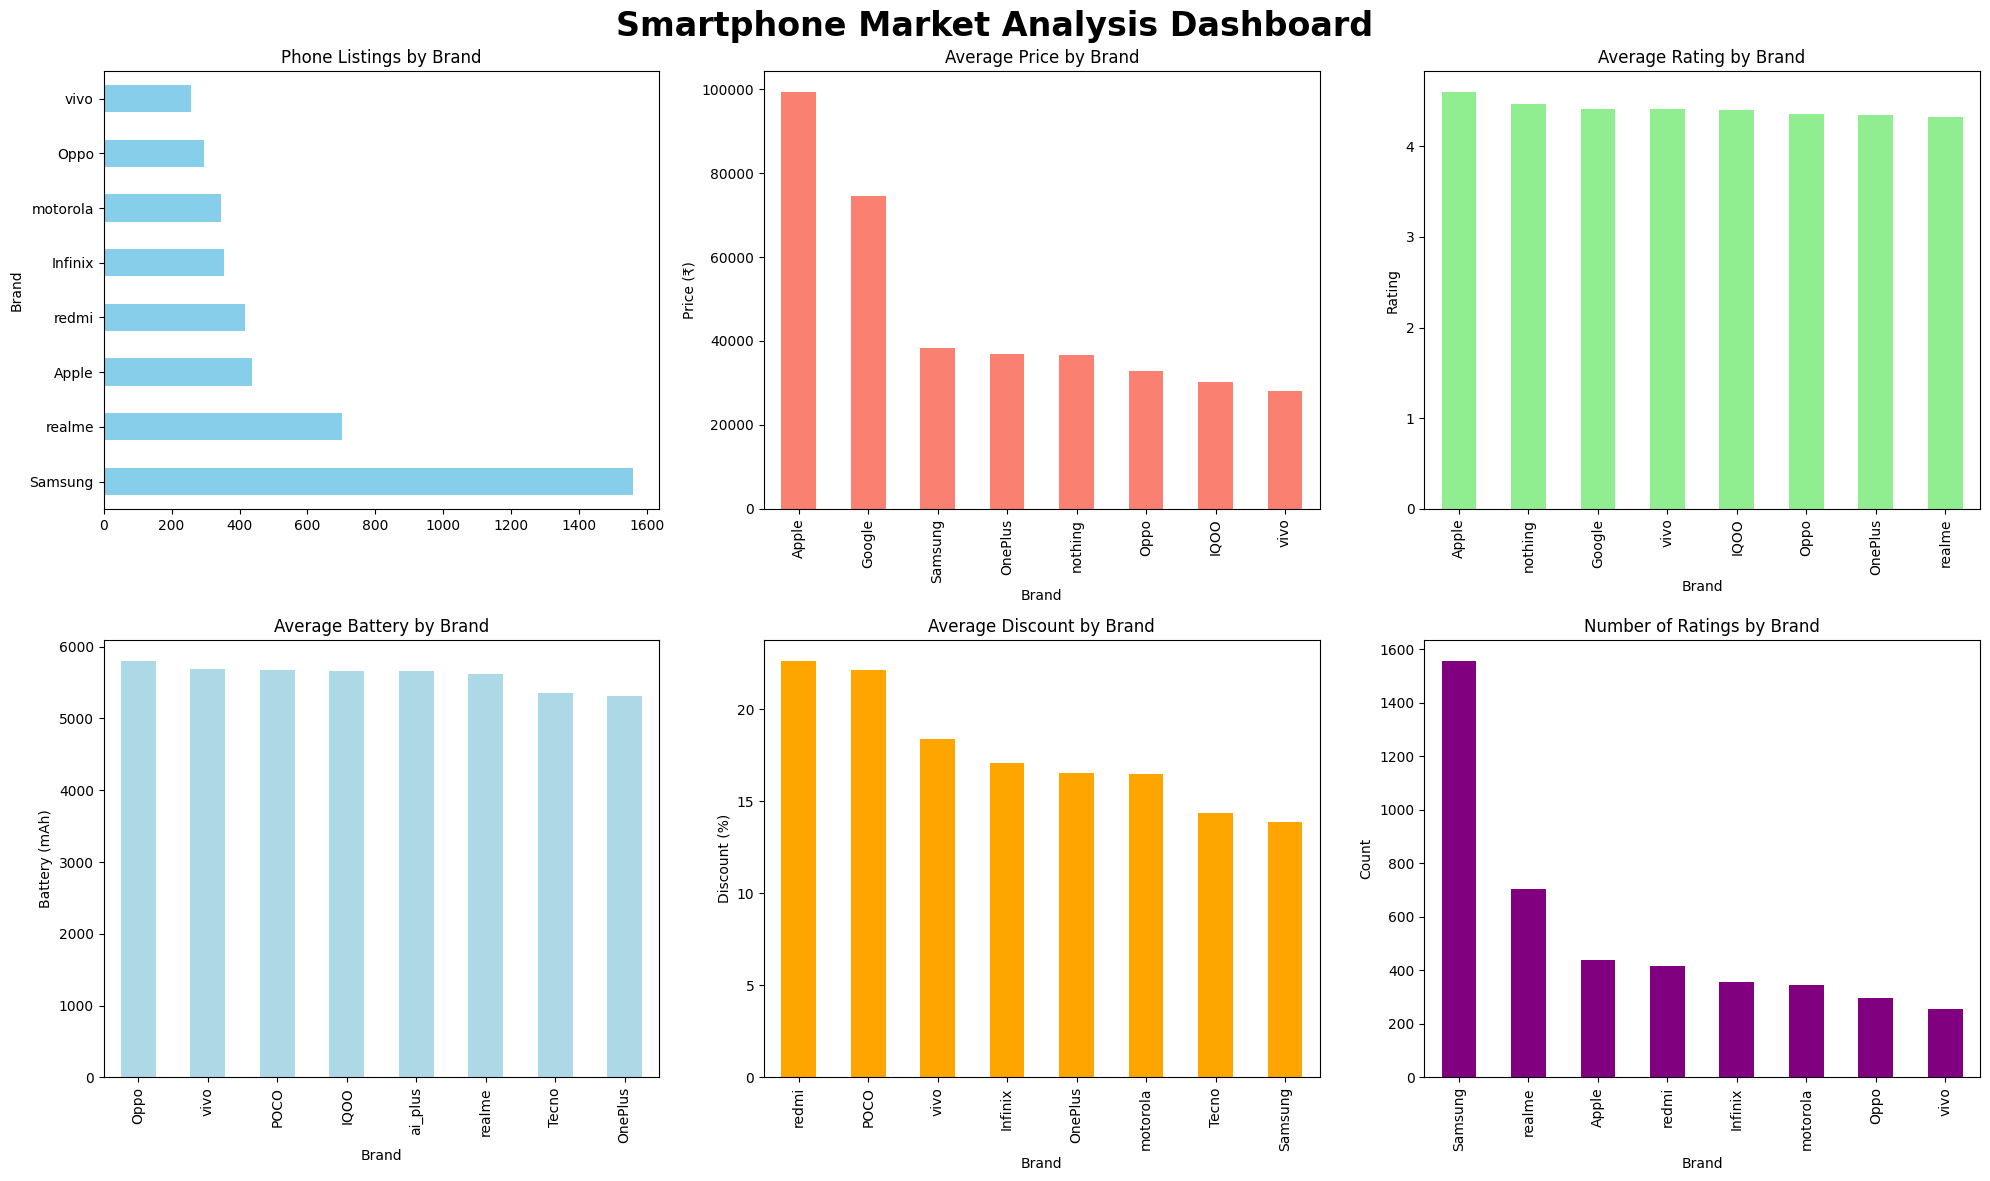

In [38]:
def create_dashboard(df):
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Phone Count
    ax1 = plt.subplot(2, 3, 1)
    df['Brand'].value_counts().head(8).plot(kind='barh', ax=ax1, color='skyblue')
    ax1.set_title('Phone Listings by Brand')
    
    # 2. Average Price
    ax2 = plt.subplot(2, 3, 2)
    df.groupby('Brand')['Current Price'].mean().sort_values(ascending=False).head(8).plot(kind='bar', ax=ax2, color='salmon')
    ax2.set_title('Average Price by Brand')
    ax2.set_ylabel('Price (₹)')
    
    # 3. Average Rating
    ax3 = plt.subplot(2, 3, 3)
    df.groupby('Brand')['Rating'].mean().sort_values(ascending=False).head(8).plot(kind='bar', ax=ax3, color='lightgreen')
    ax3.set_title('Average Rating by Brand')
    ax3.set_ylabel('Rating')
    
    # 4. Average Battery
    ax4 = plt.subplot(2, 3, 4)
    df[df['Battery'] > 0].groupby('Brand')['Battery'].mean().sort_values(ascending=False).head(8).plot(kind='bar', ax=ax4, color='lightblue')
    ax4.set_title('Average Battery by Brand')
    ax4.set_ylabel('Battery (mAh)')
    
    # 5. Average Discount
    ax5 = plt.subplot(2, 3, 5)
    df.groupby('Brand')['Discount_Number'].mean().sort_values(ascending=False).head(8).plot(kind='bar', ax=ax5, color='orange')
    ax5.set_title('Average Discount by Brand')
    ax5.set_ylabel('Discount (%)')
    
    # 6. Total Reviews
    ax6 = plt.subplot(2, 3, 6)
    reviews = df.groupby('Brand')['Rating'].count().sort_values(ascending=False).head(8)
    reviews.plot(kind='bar', ax=ax6, color='purple')
    ax6.set_title('Number of Ratings by Brand')
    ax6.set_ylabel('Count')
    
    plt.suptitle('Smartphone Market Analysis Dashboard', fontsize=24, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the dashboard
create_dashboard(df)